In [106]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [107]:
def setup_axis(x,y):
  _,ax = plt.subplots()
  ax.set_aspect('equal')
  ax.set_xlim(x)
  ax.set_ylim(y)
  ax.spines['left'].set_position('zero')
  ax.spines['bottom'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.spines['top'].set_color('none')
  for s in ax.spines.values():
    s.set_zorder(0)

  return ax

ReLU 

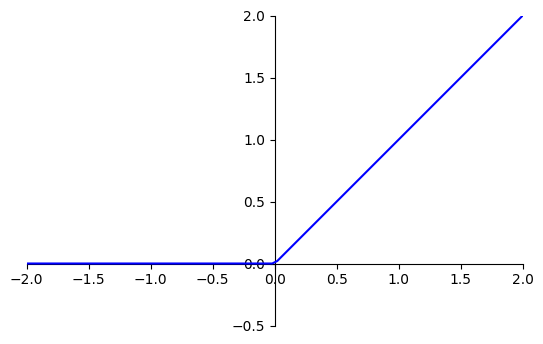

In [108]:
ax = setup_axis([-2,2],[-.5,2])
x = np.linspace(-2,2,100)
ax.plot(x, tf.keras.activations.relu(x), color='blue')

Clipping Function

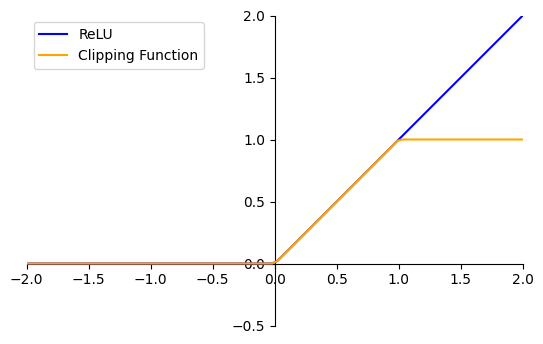

In [109]:
ax = setup_axis([-2,2],[-.5,2])
x = np.linspace(-2,2,100)
ax.plot(x, tf.keras.activations.relu(x), label='ReLU', color='blue')
ax.plot(x, tf.keras.activations.relu(x, max_value=1), label='Clipping Function', color='orange')
ax.legend()

Softplus

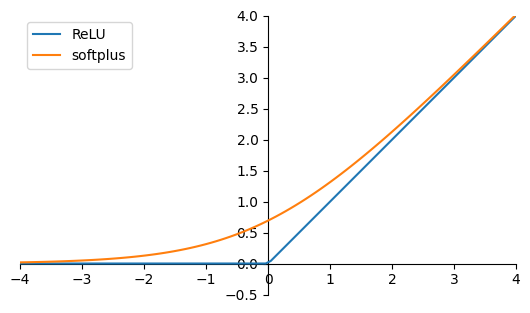

In [110]:
ax = setup_axis((-4 ,4), (-.5 ,4))
x = np.linspace(-4, 4, 100)

ax.plot(x, tf.keras.activations.relu(x), label='ReLU')
ax.plot(x, tf.keras.activations.softplus(x), label='softplus')
ax.legend()

Gaussian Error (GELU)

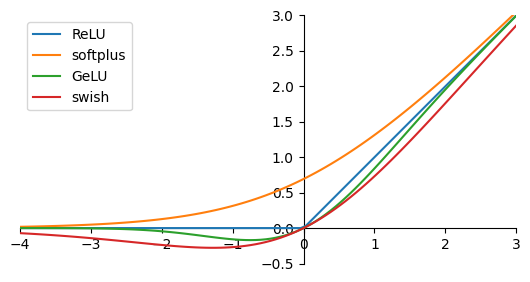

In [111]:
ax = setup_axis((-4 ,3), (-.5 ,3))
x = np.linspace(-4, 3, 100)

ax.plot(x, tf.keras.activations.relu(x), label='ReLU')
ax.plot(x, tf.keras.activations.softplus(x), label='softplus')
# ax.plot(x, tf.keras.activations.relu(x, alpha=0.1), label='leaky ReLU') ?
ax.plot(x, tf.keras.activations.gelu(x), label='GeLU')
ax.plot(x, tf.keras.activations.swish(x), label='swish')
ax.legend()

Logistic (Sigmoid)

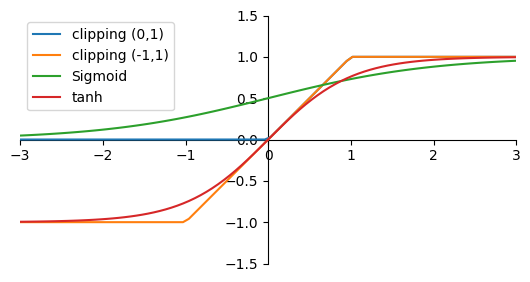

In [112]:
ax = setup_axis((-3 ,3), (-1.5 ,1.5))
x = np.linspace(-4, 3, 100)

ax.plot(x, tf.keras.activations.relu(x, max_value=1), label='clipping (0,1)')
ax.plot(x, tf.keras.activations.relu(x+1, max_value=2)-1, label='clipping (-1,1)')
ax.plot(x, tf.keras.activations.sigmoid(x), label='Sigmoid')
ax.plot(x, tf.keras.activations.tanh(x), label='tanh')
ax.legend()

ANN

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ANN1(nn.Module):
  def __init__(self):
    super().__init__()
    self.W1 = nn.Parameter(torch.Tensor([[1,0],[0,-1],[-2,2]]))
    self.B1 = nn.Parameter(torch.Tensor([0,2,-1]))
    self.W2 = nn.Parameter(torch.Tensor([[-1,2,3]]))
    self.B2 = nn.Parameter(torch.Tensor([1]))

  def forward(self, x0):
    x1 = F.relu(self.W1 @ x0 + self.B1)
    print(f"layer 1 output : {x1}")
    return F.relu(self.W2 @ x1 + self.B2)
    
model = ANN1()
x0 = torch.Tensor([1,2])

print(model.forward(x0))
print(model(x0))

for p in model.parameters():
  print(p)

layer 1 output : tensor([1., 0., 1.], grad_fn=<ReluBackward0>)
tensor([3.], grad_fn=<ReluBackward0>)
layer 1 output : tensor([1., 0., 1.], grad_fn=<ReluBackward0>)
tensor([3.], grad_fn=<ReluBackward0>)
Parameter containing:
tensor([[ 1.,  0.],
        [ 0., -1.],
        [-2.,  2.]], requires_grad=True)
Parameter containing:
tensor([ 0.,  2., -1.], requires_grad=True)
Parameter containing:
tensor([[-1.,  2.,  3.]], requires_grad=True)
Parameter containing:
tensor([1.], requires_grad=True)


In [114]:
class ANN2(nn.Module):
  def __init__(self):
    super().__init__()
    # Define the layers of the network in terms of Modules .
    # nn. Linear (3 , 20) represents an affine function defined
    # by a 20 x3 weight matrix and a 20 - dimensional bias vector .
    self.affine1 = nn.Linear(3,20)
    # The torch .nn. ReLU class simply wraps the
    # torch .nn. functional . relu function as a Module .
    self.activation1 = nn.ReLU()
    self.affine2 = nn.Linear(20,30)
    self.activation2 = nn.ReLU()
    self.affine3 = nn.Linear(30,1)


  def forward(self, x0):
    x1 = self.activation1(self.affine1(x0))
    x2 = self.activation2(self.affine2(x1))
    x3 = self.affine3(x2)
    return x3
    
model = ANN2()
x0 = torch.Tensor([1,2,3])

print(model.forward(x0))
print(model(x0))

for p in model.parameters():
  print(p)

tensor([-0.2171], grad_fn=<ViewBackward0>)
tensor([-0.2171], grad_fn=<ViewBackward0>)
Parameter containing:
tensor([[-0.3747, -0.4126, -0.0010],
        [-0.2937,  0.2067,  0.4754],
        [ 0.2397, -0.4562, -0.1818],
        [-0.0840, -0.4269, -0.0684],
        [ 0.5405,  0.0236,  0.2188],
        [-0.3169, -0.4227, -0.3371],
        [-0.1797,  0.1944, -0.4176],
        [ 0.1011, -0.3237, -0.0778],
        [-0.1960, -0.0681, -0.2678],
        [-0.3697, -0.1834,  0.5553],
        [-0.2895,  0.0092, -0.2169],
        [ 0.2075,  0.2650, -0.2556],
        [-0.3092, -0.4615,  0.2120],
        [ 0.2190, -0.1305, -0.4489],
        [-0.2081, -0.4889, -0.3219],
        [ 0.4948, -0.5172,  0.0374],
        [ 0.0593, -0.2274, -0.4084],
        [-0.4831,  0.4151,  0.3204],
        [-0.5218,  0.1341, -0.5389],
        [ 0.4103, -0.4007,  0.5598]], requires_grad=True)
Parameter containing:
tensor([-0.0313,  0.2863, -0.1486, -0.3397,  0.1556,  0.3978, -0.2578,  0.3520,
         0.2478, -0.0560, -0.

CNN (Convolutional NN)

In [123]:
import torch
import torch.nn.functional as F

class CNN1(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=(3,3))
    self.activation1 = nn.ReLU()
    self.conv2 = nn.Conv2d(in_channels=5, out_channels=5, kernel_size=(5,3))

  def forward(self, x0):
    x1 = self.activation1(self.conv1(x0))
    print(x1.shape)

    x2 = self.conv2(x1)
    print(x2.shape)
    
    return x2

model = CNN1()
x0 = torch.rand(1, 20, 20)
print(x0.shape)
print(x0)
print(model(x0))

torch.Size([1, 20, 20])
tensor([[[7.9091e-01, 9.0071e-01, 7.2120e-01, 5.1084e-01, 6.2450e-01,
          1.1601e-01, 9.9532e-01, 9.9855e-01, 7.7833e-01, 4.1584e-01,
          7.1661e-02, 9.9737e-01, 3.8737e-01, 4.7646e-01, 2.5874e-01,
          3.4899e-01, 2.2265e-01, 1.7454e-01, 3.7136e-01, 3.5193e-01],
         [2.5958e-01, 9.8151e-01, 2.3634e-01, 1.7894e-01, 8.7052e-01,
          8.5121e-01, 8.6862e-01, 9.8928e-01, 1.9995e-01, 1.6791e-01,
          5.4673e-02, 9.0241e-01, 4.2447e-01, 8.8236e-01, 7.0590e-01,
          4.2389e-01, 3.3745e-01, 4.4664e-01, 3.0411e-01, 1.5062e-01],
         [5.1153e-01, 8.0585e-02, 7.7741e-01, 9.1530e-01, 2.0432e-02,
          1.6988e-01, 4.3582e-01, 2.6293e-01, 4.9757e-01, 8.5810e-01,
          3.3605e-01, 5.4065e-01, 4.8261e-01, 3.3396e-01, 1.5027e-01,
          6.1702e-01, 1.3495e-01, 7.0431e-01, 6.3223e-02, 1.7054e-01],
         [3.3022e-01, 8.3416e-02, 8.0300e-01, 5.4387e-01, 6.3697e-01,
          1.3669e-01, 3.0488e-01, 2.5070e-01, 3.8230e-01, 7.871

In [131]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def sigmoid2(z):
  return np.exp(z)/(1 + np.exp(z))

print(sigmoid(0))
print(sigmoid(-3))

print(sigmoid2(0))
print(sigmoid2(-3))

0.5
0.04742587317756678
0.5
0.04742587317756679


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ANN3(nn.Module):
  def __init__(self):
    super().__init__()
    self.W1 = nn.Parameter(torch.rand(2, 2))
    self.B1 = nn.Parameter(torch.rand(2))
    self.W2 = nn.Parameter(torch.rand(1, 2))
    self.B2 = nn.Parameter(torch.rand(1))

  def forward(self, x0):
    x1 = F.sigmoid(self.W1 @ x0 + self.B1)
    return F.sigmoid(self.W2 @ x1 + self.B2)
  
indata = torch.Tensor([[0,0],[1,0],[0,1],[1,1]])
target = torch.Tensor([[0],[1],[1],[0]])


def compute_cost(model, indata, target):
  # Forward pass
  cost = 0
  for i in indata:
    output = model.forward(i)
    for j,k in zip(output, target):
      diff = j - k
      cost += diff * diff

  return cost / len(output)

def finite_diff(model, grad, indata, target, eps):
  params = model.parameters()
  
  cost = compute_cost(model, indata, target)

  idx = 0
  for p in params:
    p0 = p.clone()

    p = p0 + eps
    grad[idx] = (compute_cost(model, indata, target) - cost) / eps
    p = p0

def learn(model, grad, eps):
  i = 0
  for p in model.parameters():
    p.data -= eps * grad[i]
    i += 1

model = ANN3()
grad = list(model.parameters())

c0 = compute_cost(model, indata, target)
print(c0)

for i in range(10000):
  finite_diff(model, grad, indata, target, 0.01)
  learn(model, grad, 0.01)

c1 = compute_cost(model, indata, target)
print(f"cost at end {i} : {c1}")

# x0 = torch.Tensor([0,0])
# print(model.forward(x0))

# x0 = torch.Tensor([1,0])
# print(model.forward(x0))

# x0 = torch.Tensor([0,1])
# print(model.forward(x0))

# x0 = torch.Tensor([1,1])
# print(model.forward(x0))

tensor([2.5829], grad_fn=<DivBackward0>)
cost at end 9999 : tensor([1.], grad_fn=<DivBackward0>)
tensor([0.5000], grad_fn=<SigmoidBackward0>)
tensor([0.5000], grad_fn=<SigmoidBackward0>)
tensor([0.5000], grad_fn=<SigmoidBackward0>)
tensor([0.5000], grad_fn=<SigmoidBackward0>)
